## Device

In [1]:
# shared folder path
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
# path of your data that has the train and test folders
path = '/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
# path to save the trained models
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/2_stacked/'

import sys,os, glob
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

from scipy import ndimage
import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
from tqdm import tqdm
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from shared.ssim import SSIM
ssim_calc = SSIM()


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
from shared.helpful_fns import FFT,IFFT,norm_0_1,real_2_complex_shape


In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path,mask):

    # IFFT
    image = IFFT(kspace).abs()
    image_artifact = IFFT(k_space_artifact).abs()
    
    # prior
    num_diff = 6
#    num =  int(Main_Artifact_path[ Main_Artifact_path.find("slice")+num_diff:Main_Artifact_path.find(".pt")])
    num =  int(Main_Artifact_path[ Main_Artifact_path.find("slice")+num_diff:Main_Artifact_path.find("_motion")])

    path_aft = Main_Artifact_path.replace('slice_' + str(num), 'slice_' +  str(num+1))
    path_bef = Main_Artifact_path.replace('slice_' + str(num),'slice_' + str(num-1))
    
    try:
        _,K_bef_art,K_bef_mask = torch.load(path_bef, weights_only=True)
        bef_art = IFFT(K_bef_art).abs()
    except:
        K_bef_art = k_space_artifact
        K_bef_mask = mask
        bef_art = image_artifact

    try:
        _,K_aft_art,K_aft_mask = torch.load(path_aft, weights_only=True)
        aft_art = IFFT(K_aft_art).abs()
    except:
        K_aft_mask = mask
        K_aft_art = k_space_artifact
        aft_art = image_artifact

    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    bef_art = norm_0_1(bef_art)
    aft_art = norm_0_1(aft_art)    

    # View
    kspace = torch.view_as_real(kspace)
    kspace = torch.moveaxis(kspace,-1,0)
    k_space_artifact = torch.view_as_real(k_space_artifact)
    k_space_artifact = torch.moveaxis(k_space_artifact,-1,0)
    K_bef_art = torch.view_as_real(K_bef_art)
    K_bef_art = torch.moveaxis(K_bef_art,-1,0)
    K_aft_art = torch.view_as_real(K_aft_art)
    K_aft_art = torch.moveaxis(K_aft_art,-1,0)


    return  {"Arr":image[None,...],
                "Art":image_artifact[None,...],
                
                "K_bef_art":K_bef_art,
                "bef_art":bef_art[None,...],
                
                "K_aft_art":K_aft_art,
                "aft_art":aft_art[None,...],

                "K_Arr":kspace,
                "K_Art":k_space_artifact,
                
                'path':Main_Artifact_path,
                'mask':abs(mask)[None],
                'mask_bef':abs(K_bef_mask)[None],
                'mask_aft':abs(K_aft_mask)[None],
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    def __len__(self):
        return len(self.imgs_paths)
    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path, mask)

3 1200
BLUR:  tensor([0.4792])


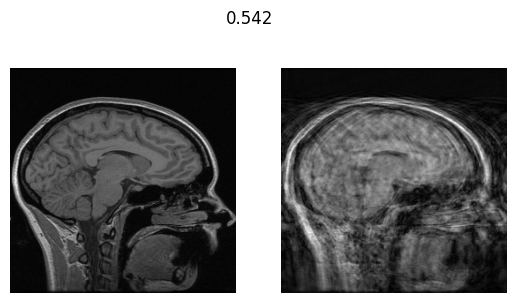

In [5]:
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 1
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cpu'    
with torch.no_grad():
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    bef = sample['bef_art'][None].to(device)
    aft = sample['aft_art'][None].to(device)
    K_Art = sample['K_Art'][None].to(device)
    K_Arr = sample['K_Arr'][None].to(device)
    plot_2_Imgs(Arr,Art)

## Model

/tmp/ipykernel_20495/4291297925.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC

-61
l/IM_MoCo//test/e14542s5_P52224.7._slice_78_motion_25.pt


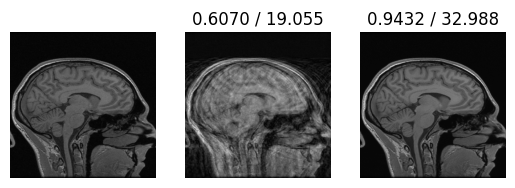

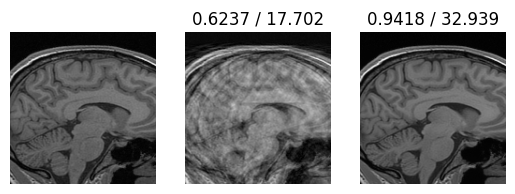

In [6]:
from hybrid_mixerprior_maskmixer import *
model = Hybrid_U_Net()#.cuda()
model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/6_Hybrid_Prior/Ablation/4_hybrid_mixerprior_maskmixer_divmask/29model.pt','cuda')

p = -61#random.randint(0,len(dataset_val))#65#285#457#-1116#-178#51
print(p)

sample= dataset_val[p]
print(sample['path'][105:])
device = 'cuda' 

with torch.no_grad():
    
      Img_arr = sample['Arr'][None].to(device)
      Art = sample['Art'][None].to(device)

      mask = sample['mask'][None].to(device)
      mask_bef = sample['mask_bef'][None].to(device)
      mask_aft = sample['mask_aft'][None].to(device)

      K_Art = sample['K_Art'][None].to(device)
      K_Arr = sample['K_Arr'][None].to(device)
      K_bef_art = sample['K_bef_art'][None].to(device)
      K_aft_art = sample['K_aft_art'][None].to(device)

      Mask_Art_out, Mask_bef_out, Mask_aft_out, k_correct, k_mix,Realout,Realout2 = model(K_Art, K_bef_art, K_aft_art)    
      
      K_Arr = real_2_complex_shape(K_Arr)
      K_Art = real_2_complex_shape(K_Art)

      K_bef_art = real_2_complex_shape(K_bef_art)
      K_aft_art = real_2_complex_shape(K_aft_art)
      k_mix = real_2_complex_shape(k_mix)
      k_correct = real_2_complex_shape(k_correct)
      
      torch.save(Realout2,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/HybridPrior_' + str(p) +'.pt')
      torch.save(Realout2[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/HybridPrior_sm_' + str(p) +'.pt')
      
      #plot_3_Imgs(Img_arr,Art, norm_0_1(abs(IFFT(k_mix))))
      plot_3_Imgs(Img_arr,Art,Realout2)
      plot_3_Imgs(Img_arr[:,:,30:-63,30:-70],Art[:,:,30:-63,30:-70],Realout2[:,:,30:-63,30:-70])
      #plot_3_Imgs(sample['Arr'][:,50:-63,30:-70],sample['Art'][:,50:-63,30:-70],Realout2[:,:,50:-63,30:-70])

## Outer

In [7]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)


input_img_3DNuFFT_sub8_run04 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run04.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = torch.view_as_complex(input_img_3DNuFFT_sub8_run04)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = F.pad( input_img_3DNuFFT_sub8_run04, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run04.shape)

input_img_3DNuFFT_sub8_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run00.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run00.shape)
#input_img_3DNuFFT_sub8_run00 = torch.view_as_complex(input_img_3DNuFFT_sub8_run00)
print(input_img_3DNuFFT_sub8_run00.shape)
input_img_3DNuFFT_sub8_run00 = F.pad( input_img_3DNuFFT_sub8_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run00.shape)


input_img_3DNuFFT_sub1_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-00_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = torch.view_as_complex(input_img_3DNuFFT_sub1_run00)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = F.pad( input_img_3DNuFFT_sub1_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run00.shape)

input_img_3DNuFFT_sub1_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = torch.view_as_complex(input_img_3DNuFFT_sub1_run01)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = F.pad( input_img_3DNuFFT_sub1_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run01.shape)


input_img_3DNuFFT_sub2_run02 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = torch.view_as_complex(input_img_3DNuFFT_sub2_run02)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = F.pad( input_img_3DNuFFT_sub2_run02, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub2_run02.shape)


input_img_3DNuFFT_sub2_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-01_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run01 = torch.view_as_complex(input_img_3DNuFFT_sub2_run01)
input_img_3DNuFFT_sub2_run01 = F.pad( input_img_3DNuFFT_sub2_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)

input_img_3DNuFFT_sub2_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-00_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run00 = torch.view_as_complex(input_img_3DNuFFT_sub2_run00)
input_img_3DNuFFT_sub2_run00 = F.pad( input_img_3DNuFFT_sub2_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)

torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])


90
BLUR: 0.456 aes:0.01460


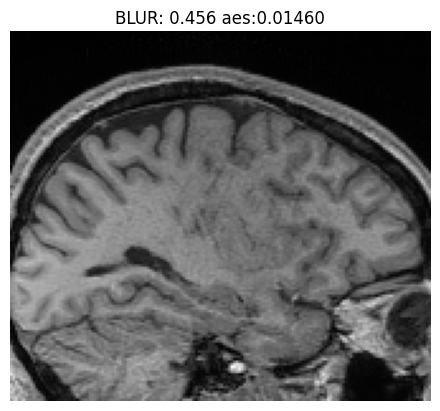

In [8]:
t = 90#t+10
print(t)

aa = input_img_3DNuFFT_sub8_run04
Art =aa[:,t-1]
Art = torch.tensor(ndimage.rotate(Art, -90))
K_Art = FFT(Art)
K_Art = torch.view_as_real(K_Art)
K_bef_art = torch.moveaxis(K_Art,-1,0)[None].cuda()

Art =aa[:,t+1]
Art = torch.tensor(ndimage.rotate(Art, -90))
K_Art = FFT(Art)
K_Art = torch.view_as_real(K_Art)
K_aft_art = torch.moveaxis(K_Art,-1,0)[None].cuda()

Art =aa[:,t]
Art = torch.tensor(ndimage.rotate(Art, -90))
K_Art = FFT(Art)
K_Art = torch.view_as_real(K_Art)
K_Art = torch.moveaxis(K_Art,-1,0)[None].cuda()


Mask_Art_out, Mask_bef_out, Mask_aft_out, k_correct, k_mix,Realout,Realout2 = model(K_Art, K_bef_art, K_aft_art)    
plot_Img(Realout2[0,0,20:-90,40:-50])        

In [32]:
with torch.no_grad():
    OUTs = []
    Arts = []
    aa = input_img_3DNuFFT_sub8_run04

    for t in tqdm(range(40,200)):


        Art =aa[:,t-1]
        Art = torch.tensor(ndimage.rotate(Art, -90))
        K_Art = FFT(Art)
        K_Art = torch.view_as_real(K_Art)
        K_bef_art = torch.moveaxis(K_Art,-1,0)[None].cuda()

        Art =aa[:,t+1]
        Art = torch.tensor(ndimage.rotate(Art, -90))
        K_Art = FFT(Art)
        K_Art = torch.view_as_real(K_Art)
        K_aft_art = torch.moveaxis(K_Art,-1,0)[None].cuda()

        Art =aa[:,t]
        Art = torch.tensor(ndimage.rotate(Art, -90))
        K_Art = FFT(Art)
        K_Art = torch.view_as_real(K_Art)
        K_Art = torch.moveaxis(K_Art,-1,0)[None].cuda()

        Mask_Art_out, Mask_bef_out, Mask_aft_out, k_correct, k_mix,Realout,Realout2 = model(K_Art, K_bef_art, K_aft_art)    

        OUTs.append(Realout2[0,0].cpu().detach())

        Art = aa[:,t]
        Art = torch.tensor(ndimage.rotate(Art, -90))
        Art = abs(Art)
        Art = norm_0_1(Art)
        Arts.append(Art.cpu().detach())

100%|██████████| 160/160 [00:30<00:00,  5.25it/s]


torch.Size([256, 160])
torch.Size([256, 160])
BLUR:  tensor([0.4782])


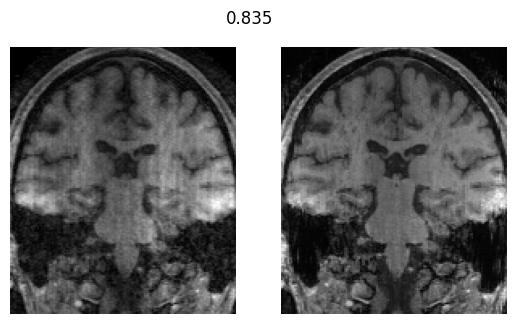

BLUR:  tensor([0.5117])


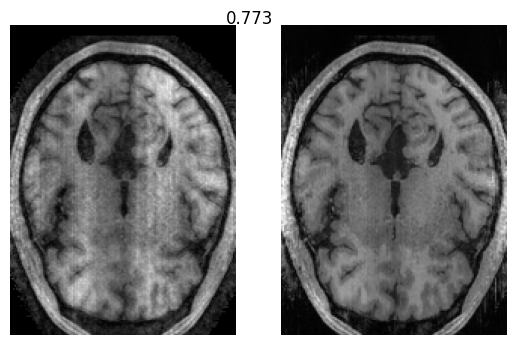

BLUR:  tensor([0.4038])


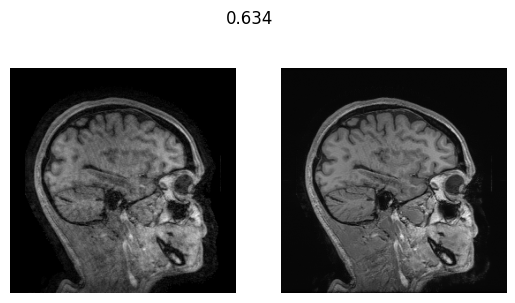

In [44]:
#t = t+10

OUT_tensor = torch.stack(OUTs)
OUT_tensor = abs(torch.tensor(ndimage.rotate(OUT_tensor[:,:,t], -90)))
print(OUT_tensor.shape)

ART_tensor = torch.stack(Arts)
ART_tensor = abs(torch.tensor(ndimage.rotate(ART_tensor[:,:,t], -90)))
print(ART_tensor.shape)

plot_2_Imgs(ART_tensor[30:-60,10:-10],OUT_tensor[30:-60,10:-10])


OUT_tensor = torch.stack(OUTs)
OUT_tensor = abs(torch.tensor(ndimage.rotate(OUT_tensor[:,t], -90)))
ART_tensor = torch.stack(Arts)
ART_tensor = abs(torch.tensor(ndimage.rotate(ART_tensor[:,t], -90)))
plot_2_Imgs(ART_tensor[10:-40,5:-5],OUT_tensor[10:-40,5:-5])

OUT_tensor = torch.stack(OUTs)
OUT_tensor = abs(torch.tensor(ndimage.rotate(OUT_tensor[t], -90)))
ART_tensor = torch.stack(Arts)
ART_tensor = abs(torch.tensor(ndimage.rotate(ART_tensor[t], -90)))
plot_2_Imgs(ART_tensor[:,0:],OUT_tensor[:,0:],rotate=True)

torch.Size([256, 236, 256])
torch.Size([256, 236])
BLUR: 0.708 aes:0.31107


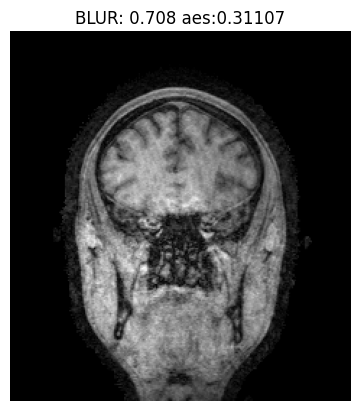

In [ ]:
t = 90#t+10
print(aa.shape)
aa_part = abs(torch.tensor(ndimage.rotate(aa[t], -90)))
print(aa_part.shape)

plot_Img(aa_part)

## Loss & Optimization

In [ ]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
import torch.nn as nn

SSIM_criterion = SSIM().cuda()
msee = nn.MSELoss()
learning_rate = 10**-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

BCE = nn.BCELoss().to(device)

## Training

In [ ]:
def normLoss(x: torch.Tensor):
    b, c, h, w = x.shape

    x = x.reshape(b, 2, c // 2 * h * w)
  
    mean = x.mean(dim=2).view(b, 2, 1, 1)
    std = x.std(dim=2).view(b, 2, 1, 1)
    x = x.reshape(b, c, h, w)
    return (x - mean) / std#, mean, std

def complex_mse_loss(y_true, y_pred):
    y_true = normLoss(y_true)
    y_pred = normLoss(y_pred)
    y_true = y_true[:,0:1,:,:] + 1j * y_true[:,1:2,:,:]
    y_pred = y_pred[:,0:1,:,:] + 1j * y_pred[:,1:2,:,:]
    msee_real = msee(y_true.real,y_pred.real)
    msee_complex = msee(y_true.imag,y_pred.imag)
    
    return msee_real + msee_complex

In [ ]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    ssim_all = 0 ;  ssim_all2 = 0; K_ssim_all = 0 ; mse_all = 0

    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        optimizer.zero_grad()
        sample = data
        Arr = Variable(data['Arr']).to(device)
        Art = Variable(data['Art']).to(device)
 
        K_Art = Variable(data['K_Art']).to(device)
        K_Arr = Variable(data['K_Arr']).to(device)
        
        K_bef_art = Variable(data['K_bef_art']).to(device)
        K_aft_art = Variable(data['K_aft_art']).to(device)
        
        mask = Variable(data['mask']).to(device)
        mask_bef = Variable(data['mask_bef']).to(device)
        mask_aft = Variable(data['mask_aft']).to(device)
        
        Mask_Art_out, Mask_bef_out, Mask_aft_out,k_correct,realout,realout2 = model(K_Art, K_bef_art, K_aft_art)    

        loss_train = BCE(Mask_Art_out, mask) +\
                    BCE(Mask_bef_out, mask_bef) +\
                    BCE(Mask_aft_out, mask_aft)+\
                    complex_mse_loss(k_correct,K_Arr)+\
                    1-SSIM_criterion(realout,Arr)+\
                    1-SSIM_criterion(realout2,Arr)
        
        loss_train.backward()
        optimizer.step()

        ssim_all += SSIM_criterion(realout2,Arr).cpu().detach()
        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , SSIM: " + str(float(ssim_all/(i+1))) + "\n")
            file1.close()
    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , loss_train: " + str(float(loss_train.cpu().detach())) + "\n"+ 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")
    file1.close()

    torch.save(model, path_model+"/"+str(epoch)+"model.pt")
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            Img_arr = Variable(datatest['Arr']).to(device)
            Art = Variable(datatest['Art']).to(device)
            
            K_Art = Variable(datatest['K_Art']).to(device)
            K_Arr = Variable(datatest['K_Arr']).to(device)

            K_bef_art = Variable(datatest['K_bef_art']).to(device)
            K_aft_art = Variable(datatest['K_aft_art']).to(device)

            mask = Variable(datatest['mask']).to(device)
            mask_bef = Variable(datatest['mask_bef']).to(device)
            mask_aft = Variable(datatest['mask_aft']).to(device)
                        
            
            Mask_Art_out, Mask_bef_out, Mask_aft_out,_,_,realout2 = model(K_Art, K_bef_art, K_aft_art)    

            loss_ = SSIM_criterion(realout2,Img_arr)
          
            ssim_all += loss_.cpu().detach()

      print("Test ssim_all: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , ssim_all: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
from shared.mutualInfo import mutual_information
import time

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
times = []

with torch.no_grad():
  ssim_all = [] ; psnr_bef=[] ; ssim_all_bef = []; mse_all = [] ; mse_all_bef = [] 
  psnr=[] ; BLUR = [] ; BLUR_BEF = []
  MI = [] ; MI_BEF = []   
  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:

        path_ = (datatest['path'])[0]
        Arr = Variable(datatest['Arr']).to(device)
        Art = Variable(datatest['Art']).to(device)
        K_Art = Variable(datatest['K_Art']).to(device)
        K_Arr = Variable(datatest['K_Arr']).to(device)
        
        K_bef_art = Variable(datatest['K_bef_art']).to(device)
        K_aft_art = Variable(datatest['K_aft_art']).to(device)

        a = time.time()
        _,_,_,_,k_mix, real_correct, outputs_test = model(K_Art, K_bef_art, K_aft_art)  
        times.append(time.time()-a)

        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        paft = float(metric.compute())
        psnr.append( paft)

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        pbef = float(metric.compute())
        psnr_bef.append( pbef)

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())


        MI .append( mutual_information(Arr,outputs_test))
        MI_BEF .append( mutual_information(Arr,Art))

        # save
        p = '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/6_Hybrid_Prior/Ablation/4_hybrid_mixerprior_maskmixer_divmask/data/'
        with open(p+ 'ssim_all.txt', 'a') as f:
            f.write( str(float(SSIM_criterion(outputs_test, Arr).cpu().detach())) + "\n" )
        with open(p+ 'ssim_all_bef.txt', 'a') as f:
            f.write( str(float(SSIM_criterion(Art, Arr).cpu().detach())) + "\n" )

        with open(p+ 'psnr_all.txt', 'a') as f:
            f.write( str(paft) + "\n" )
        with open(p+ 'psnr_all_bef.txt', 'a') as f:
            f.write( str(pbef) + "\n" )

        with open(p+ 'blur_all.txt', 'a') as f:
            f.write( str(float(torch.sum(b(outputs_test)).cpu().detach()))  + "\n" )
        with open(p+ 'blur_all_bef.txt', 'a') as f:
            f.write( str(float(torch.sum(b(Art)).cpu().detach())) + "\n" )
        
        with open(p+ 'MI_all.txt', 'a') as f:
            f.write( str(float(mutual_information(Arr,outputs_test)))  + "\n" )
        with open(p+ 'MI_all_bef.txt', 'a') as f:
            f.write( str(float(mutual_information(Arr,Art))) + "\n" )
        
        with open(p+ 'path.txt', 'a') as f:
            f.write( path_ + "\n" )

100%|██████████| 1200/1200 [02:39<00:00,  7.52it/s]


In [ ]:
print("mse aft std :",np.std(mse_all), "mse mean :",np.mean(mse_all))
print("mse bef std :",np.std(mse_all_bef), "mse mean :",np.mean(mse_all_bef) ,"\n")

print("ssim aft std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))
print("ssim bef std :",np.std(ssim_all_bef), "ssim mean :",np.mean(ssim_all_bef) ,"\n")

print("psnr aft std :",np.std(psnr), "psnr mean :",np.mean(psnr))
print("psnr bef std :",np.std(psnr_bef), "psnr mean :",np.mean(psnr_bef),"\n")

print("Blur aft std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))
print("Blur bef std :",np.std(BLUR_BEF), "Blur mean :",np.mean(BLUR_BEF),"\n")

print("MI aft std :",np.std(MI), "MI mean :",np.mean(MI))
print("MI bef std :",np.std(MI_BEF), "MI mean :",np.mean(MI_BEF),"\n")

print("time std :",np.std(times), "MI mean :",np.mean(times),"\n")

mse aft std : 0.07944315 mse mean : 0.07568911
mse bef std : 0.19240074 mse mean : 0.27484894 

ssim aft std : 0.08355553043881381 ssim mean : 0.8938706311583519
ssim bef std : 0.12453755104871833 ssim mean : 0.7658770545820395 

psnr aft std : 6.657408226764062 psnr mean : 32.92429704348246
psnr bef std : 5.026714467870823 psnr mean : 25.071650342941282 

Blur aft std : 0.025082085 Blur mean : 0.4286093
Blur bef std : 0.021324178 Blur mean : 0.44909087 

MI aft std : 0.2779566339411621 MI mean : 1.3738347612908979
MI bef std : 0.2738904738789271 MI mean : 1.003781371839761 

time std : 0.0013769626178053989 MI mean : 0.10707274357477824 



In [ ]:
1200/(3*60+19.8)